In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
cv2.putText
cv2.rectangle
cv2.circle
cv2.fillPoly

In [ ]:
# 엣지 검출
# 소벨 1차 미분
sample_img_rgb = None
sobel_x = cv2.Sobel(
    sample_img_rgb,
    cv2.CV_64F, # 출력 이미지 타입 지정(64비트 float)
    1, # x방향 미분 차수 (1=1차 미분)
    0, # y방향 미분 차수 (0=0차 미분)
    ksize=3 # 커널 사이즈
)

# sobel_x = np.uint8(sobel_x)

sobel_y = cv2.Sobel(
    sample_img_rgb,
    cv2.CV_64F, # 출력 이미지 타입 지정(64비트 float)
    0, # x방향 미분 차수 (0=0차 미분)
    1, # y방향 미분 차수 (1=1차 미분)
    ksize=3 # 커널 사이즈
)

sobel_combined2 = cv2.magnitude(sobel_x, sobel_y) # 거리 계산(피타고라스) # 타입이 실수여야함
sobel_combined2 = np.uint8(sobel_combined2)
sobel_x = np.uint8(np.absolute(sobel_x))
sobel_y = np.uint8(np.absolute(sobel_y))
sobel_combined = cv2.addWeighted(sobel_x,0.5,
                                 sobel_y,0.5,
                                 0) # 0.5*sobel_x + 0.5*sobel_y + 0



# 라플라시안 2차 미분
laplacian = cv2.Laplacian(
    sample_img_rgb,
    cv2.CV_64F,
)


# 끝판왕
# 캐니
sample_img_gray = cv2.cvtColor(sample_img_rgb, cv2.COLOR_RGB2GRAY)

canny = cv2.Canny(sample_img_gray, # 1채널(gray)만 가능
          50, # 최소임계값: 50 이하면 무조건 제외
          150) # 최대임계값: 무조건 포함 # 만약에 이 사이면 엣지에 연결되어 있으면 엣지 아니면 지움

plt.imshow(canny,cmap='gray')

In [ ]:
# 아핀변환
m = cv2.getRotationMatrix2D((112,112), # 회전 중심점
                         45, # 회전 각도(반시계+)
                         0.5) # 스케일

src_pts = np.float32([[50,50],[350,50],[50,350]])
dst_pts = np.float32([[80,100],[320, 80],[100, 320]])
m = cv2.getAffineTransform(
    src_pts,
    dst_pts
)


cv2.warpAffine(sample_img_rgb,
                m,
                (224,224),
                )

# 투영 변환
perspective_matrix = cv2.getPerspectiveTransform(
    src_pts, # 4개의 점
    dst_pts  # 4개의 점
)
cv2.warpPerspective(
    sample_img_rgb,
    perspective_matrix, # 3x3 변환 행렬
    (224,224),
    borderValue=(200,200,200)
)

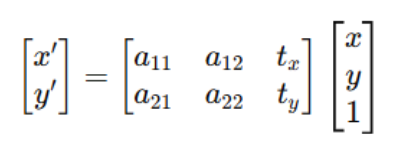

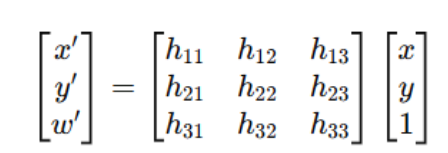

정확히는 h33=1로 고정임

In [ ]:
# 보간법

cv2.resize(sample_img_rgb,(448,448),interpolation=cv2.INTER_NEAREST)
# 순서대로 계산이 단순 빠름
cv2.INTER_NEAREST
cv2.INTER_LINEAR
cv2.INTER_CUBIC
cv2.INTER_LANCZOS4
